## 0. Introduction

The aim of this lab is to get familiar with **classification problems** and **logistic regression**. We will be using some code extracts that were implemented last week and build a logistic regression model.

1.   This lab is the second course-work activity **Assignment 1 Part 2: Classification**
2. Assignment 1 is split into 3 parts: Part 1 - Regression (Lab 3), and Part 2 - Classification (Lab 4) and Part 3 - Neural Networks (Lab 6). The three parts need to be submitted together by  **Monday, 11th November 2024, 10:00am**
3. All questions need to be completed and are assessed.
4. For each lab, a report answering the <font color = 'red'>**questions in red**</font> should be included along with the completed Notebook (.ipynb)
5. The report should be a separate file in **pdf format** (so **NOT** *doc, docx, notebook* etc.).
6. Make sure that **any figures or code** you comment on, are **included in the report**.
7. There are three parts of Assignment 1, therefore you should submit a zip file that contains 1 x Notebook and 1 x PDF for each part. In total: 3 x Notebooks and 3 x PDFs in the submission zip. Make sure the file is well identified with your name, student number, assignment number (for instance, Assignment 1), module code.
7. No other means of submission other than the appropriate QM+ link is acceptable at any time (so NO email attachments, etc.)
8. **PLAGIARISM** <ins>is an irreversible non-negotiable failure in the course</ins> (if in doubt of what constitutes plagiarism, ask!).


For this lab, we will be using the [iris dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#iris-dataset).

In [1]:
import torch
from torch import nn
from torch import optim
from torch.nn import functional as F
from sklearn import model_selection
from sklearn import datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
from IPython import display

import typing
%matplotlib inline

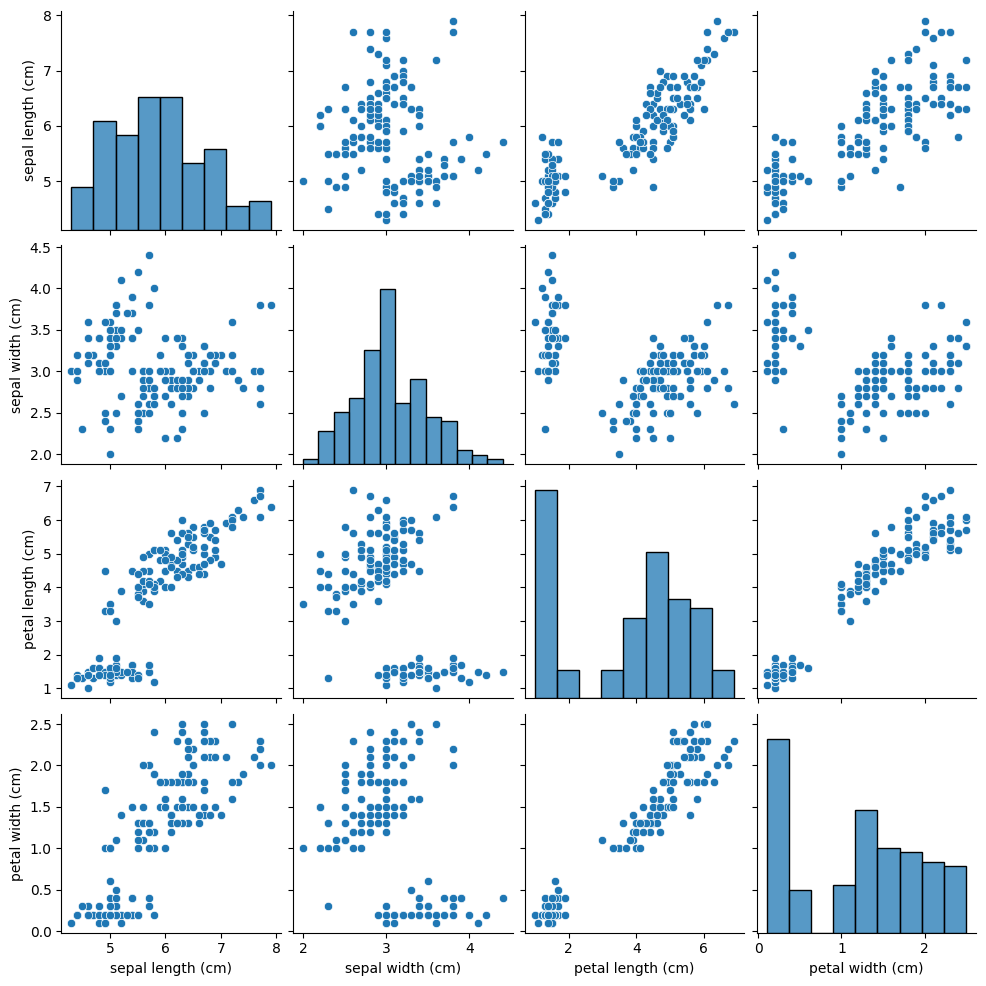

In [2]:
iris_db = datasets.load_iris(as_frame=True)
sn.pairplot(iris_db.data)

In [3]:
iris_db.data.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1


We will split the data into train and test sets. For consistency and to allow for meaningful comparison the same splits are maintained in the remainder of the lab.

In [4]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    iris_db.data,
    iris_db.target,
    test_size=0.2,
    random_state=42
    )
x_train = torch.from_numpy(X_train.values).float()
x_test = torch.from_numpy(X_test.values).float()

y_train = torch.from_numpy(y_train.values).int()
y_train = y_train.reshape(-1, 1)

y_test = torch.from_numpy(y_test.values).int()
y_test = y_test.reshape(-1, 1)

#Cloning the raw data so I can plot both raw and normalised data
X_train_raw = x_train.clone()

<font color="red">**Q1.** We again notice that the attributes are on different scales. Use the normalisation method from last lab, to standardize the scales of each attribute on both sets. Plot the normalized and raw training sets; what do you observe? [2 marks] </font>

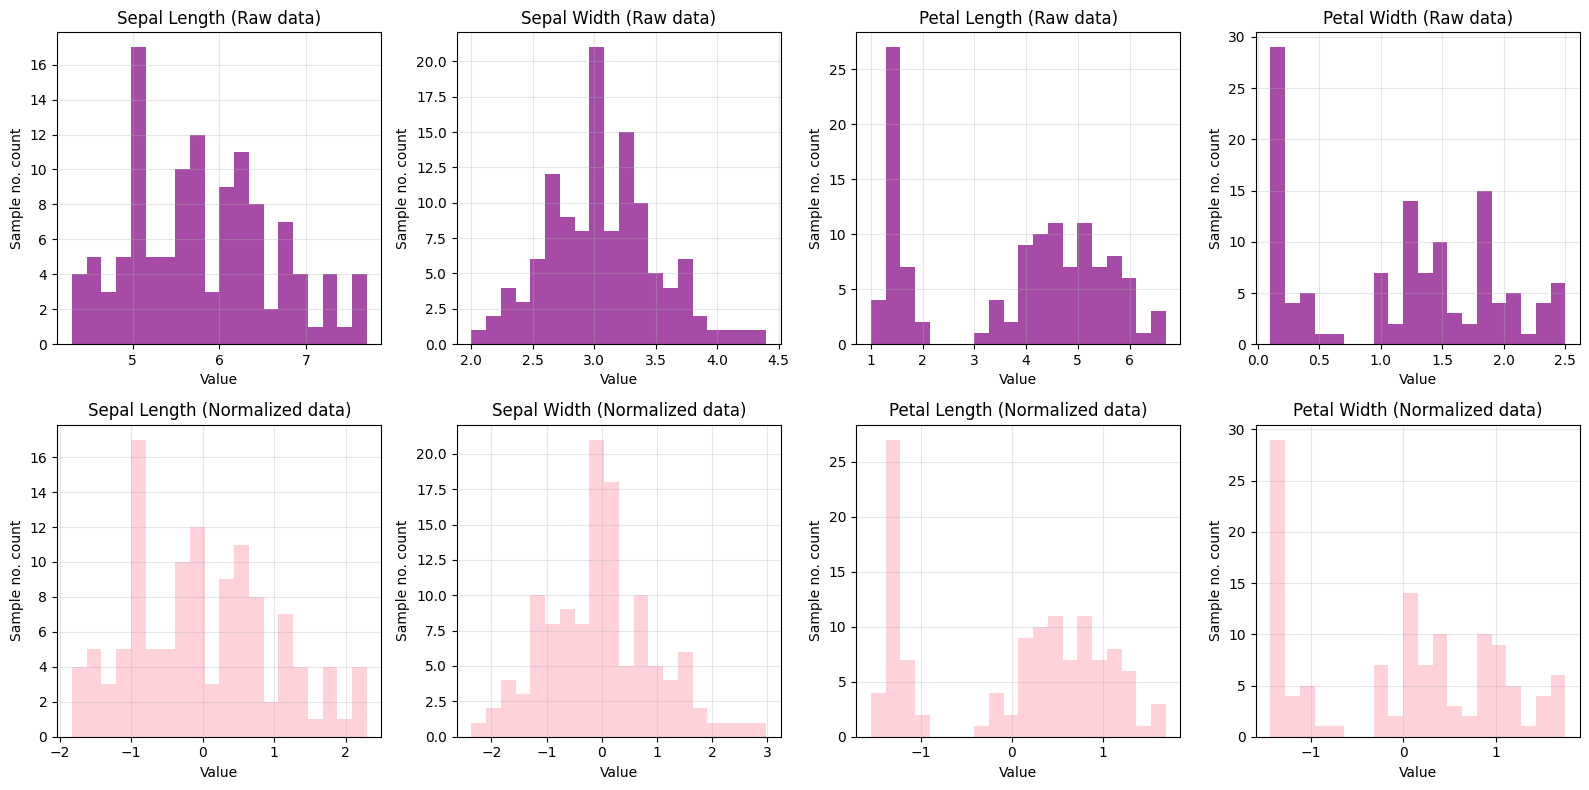

Raw Training Data Statistical Analysis:
       Sepal Length  Sepal Width  Petal Length  Petal Width
count    120.000000   120.000000    120.000000   120.000000
mean       5.809167     3.061667      3.726666     1.183333
std        0.823805     0.449123      1.752344     0.752289
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.500000     0.300000
50%        5.750000     3.000000      4.250000     1.300000
75%        6.400000     3.400000      5.100000     1.800000
max        7.700000     4.400000      6.700000     2.500000

Normalized Training Data Statistical Analysis:
       Sepal Length   Sepal Width  Petal Length   Petal Width
count  1.200000e+02  1.200000e+02  1.200000e+02  1.200000e+02
mean   2.622604e-07 -1.351039e-07 -3.576279e-08  6.755193e-08
std    1.000000e+00  9.999999e-01  9.999999e-01  9.999996e-01
min   -1.831946e+00 -2.363866e+00 -1.556011e+00 -1.440050e+00
25%   -8.608426e-01 -5.826172e-01 -1.270679e+00 -1.174194e+00


In [5]:
### your code here

#Normalising function taken from Regression lab
def norm_set(x: torch.Tensor, mu: torch.Tensor, sigma: torch.Tensor) -> torch.Tensor:
    x_norm = (x - mu) / sigma
    return x_norm

mu = x_train.mean(dim=0, keepdim=True)
sigma = x_train.std(dim=0, keepdim=True)

x_train = norm_set(x_train, mu, sigma)
x_test = norm_set(x_test, mu, sigma)

# Ploting the raw and normalized for Sepal length, width and Petal length and width
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

features = ['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width']

# Plotting the raw training data sets and plotting the normalized training data sets
for i in range(4):
  #For i Sepal length = 0, Sepal width = 1, Petal length = 2, petal width= 3
    axes[0, i].hist(X_train_raw[:, i].numpy(), bins=20, color='purple', alpha=0.7)
    axes[0, i].set_title(f'{features[i]} (Raw data)')
    axes[0, i].set_xlabel('Value')
    axes[0, i].set_ylabel('Sample no. count')
    axes[0, i].grid(alpha=0.3)

    axes[1, i].hist(x_train[:, i].numpy(), bins=20, color='pink', alpha=0.7)
    axes[1, i].set_title(f'{features[i]} (Normalized data)')
    axes[1, i].set_xlabel('Value')
    axes[1, i].set_ylabel('Sample no. count')
    axes[1, i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#Statistical analysis for observations, printing mean, std, and the min and max value, with quartiles,
print("Raw Training Data Statistical Analysis:")
print(pd.DataFrame(X_train_raw.numpy(), columns=features).describe())
print("\nNormalized Training Data Statistical Analysis:")
print(pd.DataFrame(x_train.numpy(), columns=features).describe())


By inspecting the dataset we see that it contains 4 attributes. (`sepal length`, `sepal width`, `petal length`, `petal width`, in centimeters). For simplicity we will focus on the first two.

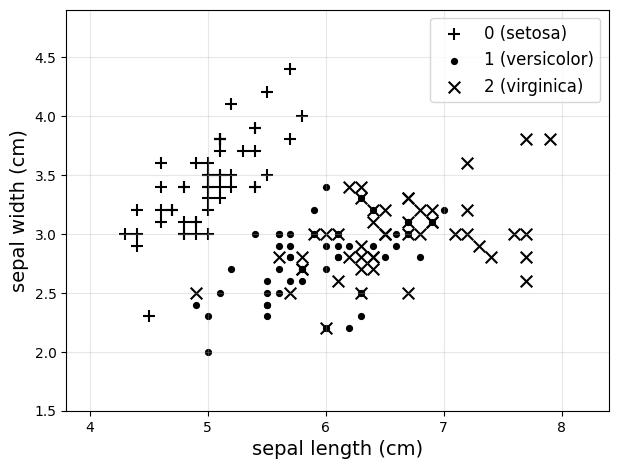

Statistical Analysis for Sepal Length and Sepal Width:
       sepal length (cm)  sepal width (cm)
count         150.000000        150.000000
mean            5.843333          3.057333
std             0.828066          0.435866
min             4.300000          2.000000
25%             5.100000          2.800000
50%             5.800000          3.000000
75%             6.400000          3.300000
max             7.900000          4.400000


In [6]:
X = iris_db.data.iloc[:, :2]
Y = iris_db.target
marker_list = ['+', '.', 'x']
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111)
ax.set_aspect('equal')

for l in [0, 1, 2]:
  ax.scatter(
      X.loc[Y == l].iloc[:, 0],
      X.loc[Y == l].iloc[:, 1],
      marker=marker_list[l],
      s=70,
      color='black',
      label='{:d} ({:s})'.format(l, iris_db.target_names[l])
      )

ax.legend(fontsize=12)
ax.set_xlabel(iris_db.feature_names[0], fontsize=14)
ax.set_ylabel(iris_db.feature_names[1], fontsize=14)
ax.grid(alpha=0.3)
ax.set_xlim(X.iloc[:, 0].min() - 0.5, X.iloc[:, 0].max() + 0.5)
ax.set_ylim(X.iloc[:, 1].min() - 0.5, X.iloc[:, 1].max() + 0.5)
plt.show()

#Statistical analysis for Sepal length and width
print("Statistical Analysis for Sepal Length and Sepal Width:")
print(X.describe())


Is the data linearly separable?

As there are multiple classes, for now we will focus on class 0 (setosa). As such, we modify the `y_train` and `y_test` tensors, so that each label is 1 if the class is setosa and 0 if otherwise.

In [7]:
train_set_1 = x_train[:, :2]
test_set_1 = x_test[:, :2]

# add a feature for bias
train_set_1 = torch.cat([train_set_1, torch.ones(train_set_1.shape[0], 1)], dim=1)
test_set_1 = torch.cat([test_set_1, torch.ones(test_set_1.shape[0], 1)], dim=1)

setosa_train = (y_train == 0).int()
setosa_test = (y_test == 0).int()

## 1. Sigmoid function
With logistic regression the values we want to predict are now discrete classes, not continuous variables. In other words, logistic regression is for classification tasks. In the binary classification problem we have classes $0$ and $1$, e.g. classifying email as spam or not spam based on words used in the email.

The logistic/sigmoid function given by the formula below:

$ h_{\theta}(x) = g(\theta^{T}x) =  \frac{1}{1+ e^{-\theta^Tx}} $

**Q2.** First implement the above function in `def sigmoid()`. [2 marks]

**Q3.** Then, using the implementation of `LinearRegression` from last week as guideline, create a custom pytorch layer for `LogisticRegression` [2 marks]

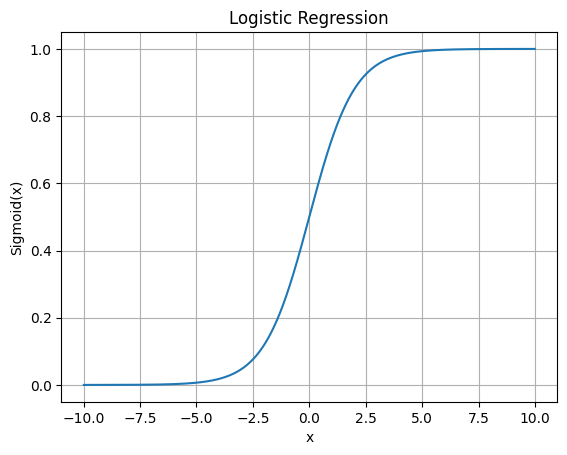

In [8]:
def sigmoid(z: torch.Tensor) -> torch.Tensor:
  ### your code here
  z = 1 / (1 + torch.exp(-z))
  return z


x = torch.arange(1,2000, 1)/100.0 - 10
y = sigmoid(x)
fig, ax1 = plt.subplots()
ax1.plot(x, y)
# set label of horizontal axis
ax1.set_title('Logistic Regression')
ax1.set_xlabel('x')
# set label of vertical axis
ax1.set_ylabel('Sigmoid(x)')
plt.grid(True)
plt.show()

In [9]:
class LogisticRegression(nn.Module):
  def __init__(self, num_features):
      super().__init__()
      self.weight = nn.Parameter(torch.zeros(1, num_features), requires_grad=False)

  def forward(self, x):
      y = 0
      z = torch.matmul(x, self.weight.T)
      y = 1 / (1 + torch.exp(-z))
      return y


The cost function we will use for logistic regression is the **Cross Entropy Loss**, which is given by the form:

$J(\theta) = \frac{1}{m} \sum_{i=1}^m \left[ \left(- y^{(i)} log( h_{\theta}(x^{(i)})) - (1-y^{(i)})log(1-h_{\theta}(x^{(i)}))    \right) \right] $

Which when taking partial derivatives and putting these into the gradient descent update equation gives


$
 \theta_{j} =  \theta_{j} - \alpha \frac{1}{m}  \sum_{i=1}^m ( h_{\theta}(x^{(i)}) - y^{(i)})x^{(i)}_{j}
$

**Q4.** Implement the cost in `bce()` and update the `gradient_descent_step()` from last week to update using the partial derivative above. [4 marks]

In [10]:
def bce(y_true: torch.Tensor, y_pred: torch.Tensor) -> torch.Tensor:
  ### your code here
  #Cross entropy loss: J(@) = (1/m) * sum (-y *log(h@(x)) - (1-y)*log(1- h@(x))
  n = y_true.shape[0]
  loss = (-1/n) * torch.sum(y_true * torch.log(y_pred) + (1 - y_true) * torch.log(1 - y_pred))
  return loss

def gradient_descent_step(model: nn.Module, X: torch.Tensor, y: torch.Tensor, y_pred: torch.Tensor, lr: float) -> None:
  weight = model.weight
  N = X.shape[0]
  ### your code here
  # dervied from the Cross entropy loss
  # dj/dw = (1/m) * sum(h@(x) - y) * x
  gradient = (1 / N) * torch.matmul(X.T, (y_pred - y))

  #update the weights using the gradient decent
  #@ = @ - alph * dj/dl
  weight = weight - lr * gradient.T
  model.weight = nn.Parameter(weight, requires_grad=False)

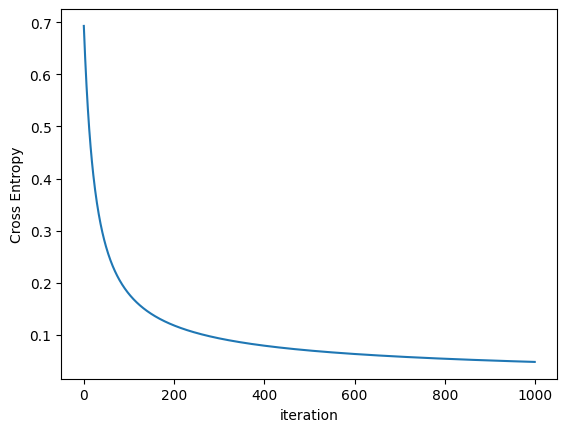

Parameter containing:
tensor([[-3.7662,  2.5406, -2.1241]])
Minimum cost: 0.047883812338113785


In [11]:
def train(model, x, y, alpha):
  cost_lst = list()
  for it in range(1000):
    prediction = model(x)
    cost = bce(y, prediction)
    cost_lst.append(cost)
    gradient_descent_step(model, x, y, prediction, alpha) #added prediction so 5 passing arguements

  display.clear_output(wait=True)
  plt.plot(list(range(it+1)), cost_lst)

  plt.xlabel('iteration')
  plt.ylabel('Cross Entropy')

  plt.show()
  print(model.weight)
  print('Minimum cost: {}'.format(min(cost_lst)))

model = LogisticRegression(train_set_1.shape[1])
alpha = 0.1
# select an appropriate lr
train(model, train_set_1, setosa_train, alpha)

<font color="red"> **Q5.** Draw the decision boundary on the test set using the learned parameters. Is this decision boundary separating the classes? Does this match our expectations? [2 marks]</font>

Test Set Statistics by Class:

Setosa samples (class 1):
       Sepal Length  Sepal Width
count     10.000000    10.000000
mean      -0.897259     0.597461
std        0.420695     0.672489
min       -1.346395    -0.137305
25%       -1.225006     0.085351
50%       -1.042924     0.530664
75%       -0.587720     0.920312
max       -0.132515     1.643944

Non-Setosa samples (class 0):
       Sepal Length  Sepal Width
count     20.000000    20.000000
mean       0.759687    -0.371094
std        0.747534     0.759285
min       -0.253903    -1.918554
25%        0.322690    -0.638281
50%        0.717201    -0.471289
75%        1.111711    -0.081641
max        2.538020     1.643944



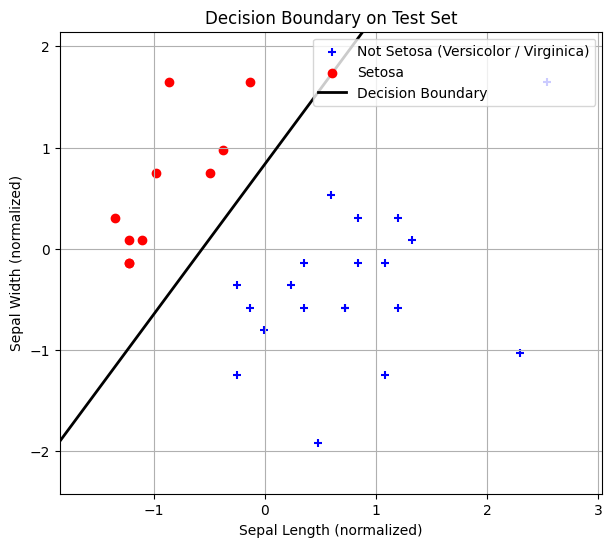

Classification Summary:
Total test samples: 30
Setosa samples: 10
Non-Setosa samples: 20


In [12]:
### your code here

# w1 (w[0]) is -0.2909, w2 (w[1]) is 0.2537, wb (w[2]) is -0.1478 - numbers change
# training parameters and converting them into a numpy array
w = model.weight.detach().numpy().flatten()
wb = w[2]

# Use setosa_test for binary classification (not y_test!)
setosa_test_flat = setosa_test.flatten()

# Print statistics for each class
print("Test Set Statistics by Class:")
print("\nSetosa samples (class 1):")
print(pd.DataFrame(test_set_1[setosa_test_flat==1, :2].numpy(), columns=['Sepal Length', 'Sepal Width']).describe())

print("\nNon-Setosa samples (class 0):")
print(pd.DataFrame(test_set_1[setosa_test_flat==0, :2].numpy(), columns=['Sepal Length', 'Sepal Width']).describe())
print()


plt.figure(figsize=(7,6))
plt.scatter(test_set_1[setosa_test_flat==0, 0], test_set_1[setosa_test_flat==0, 1], color='blue', label='Not Setosa (Versicolor / Virginica)', marker='+')
plt.scatter(test_set_1[setosa_test_flat==1, 0], test_set_1[setosa_test_flat==1, 1], color='red', label='Setosa', marker='o')

# for logistic regression the equation w'^TX' = w^Tx + wb (vector form). (w1x1 + w2x2 + wb) for decision boundary
# rearrange to get x2 values
# x2 = -(w1/w2) * x1 - (wb/w2)
x1 = np.linspace(test_set_1[:,0].min()-0.5, test_set_1[:,0].max()+0.5, 100)
x2 = - (w[0]/w[1]) * x1 - (wb / w[1])
plt.plot(x1, x2, color='black', linewidth=2, label='Decision Boundary')

plt.xlabel('Sepal Length (normalized)')
plt.ylabel('Sepal Width (normalized)')
plt.title('Decision Boundary on Test Set')
plt.legend(loc='upper right')
plt.grid(True)
plt.xlim(test_set_1[:,0].min()-0.5, test_set_1[:,0].max()+0.5)
plt.ylim(test_set_1[:,1].min()-0.5, test_set_1[:,1].max()+0.5)
plt.show()

# Print classification summary
print("Classification Summary:")
print(f"Total test samples: {len(setosa_test_flat)}")
print(f"Setosa samples: {(setosa_test_flat==1).sum()}")
print(f"Non-Setosa samples: {(setosa_test_flat==0).sum()}")

## 2. Multiclass
So far, we have focused on a binary classification (is this iris setosa or not), however in this section we will address the problem as a multiclass classification. We will be using a 1 vs. all approach (refer to the lecture notes for details). We will also be using all 4 attributes for the classification.

Firstly, we need to process `y_train, y_test` so that each label is a vector rather than an integer.

In [13]:
y_train = F.one_hot(y_train.reshape(-1).long(), num_classes=3)
y_test = F.one_hot(y_test.reshape(-1).long(), num_classes=3)
print(y_test.shape)

torch.Size([30, 3])


In this section we will use the built in pytorch methods.


In [14]:
alpha = 0.1
setosa_model = nn.Sequential(nn.Linear(x_train.shape[1], 1, bias=False), nn.Sigmoid())
setosa_labels = y_train[:, 0].reshape(-1, 1).float()
setosa_testy = y_test[:, 0].reshape(-1, 1).float()
optimiser = optim.SGD(setosa_model.parameters(), alpha)

def train(model, x, y, test_x, test_y, optimiser, alpha):
  train_lst = list()
  test_lst = list()
  for i in range(1000):
    model.train()
    optimiser.zero_grad()
    pred = model(x)
    cost = F.binary_cross_entropy(pred, y, reduction='mean')
    cost.backward()
    train_lst.append(cost.item())
    optimiser.step()
    model.eval()
    with torch.no_grad():
      test_pred = model(test_x)
      test_cost = F.binary_cross_entropy(test_pred, test_y, reduction='mean')
      test_lst.append(test_cost)
  fig, axs = plt.subplots(2)
  axs[0].plot(list(range(i+1)), train_lst)
  axs[1].plot(list(range(i+1)), test_lst)
  plt.show()
  print('Minimum train cost: {}'.format(min(train_lst)))
  print('Minimum test cost: {}'.format(min(test_lst)))


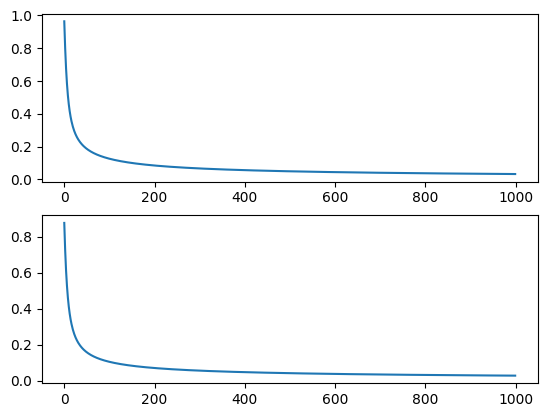

Minimum train cost: 0.03202846273779869
Minimum test cost: 0.02751031704246998


In [15]:
train(setosa_model, x_train, setosa_labels, x_test, setosa_testy, optimiser, alpha)

How does the cost of the 4 attribute model compare to the previous one?

**Q6** Now train classifiers for the other two classes.[1 mark]

Training Versicolor Classifier (1 vs all):


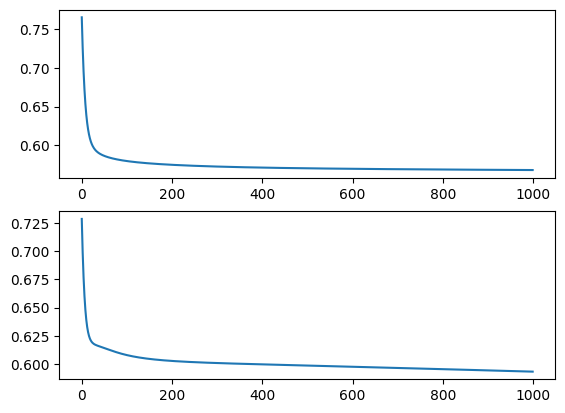

Minimum train cost: 0.5679900050163269
Minimum test cost: 0.5933138728141785

Training Virginica Classifier (1 vs all):


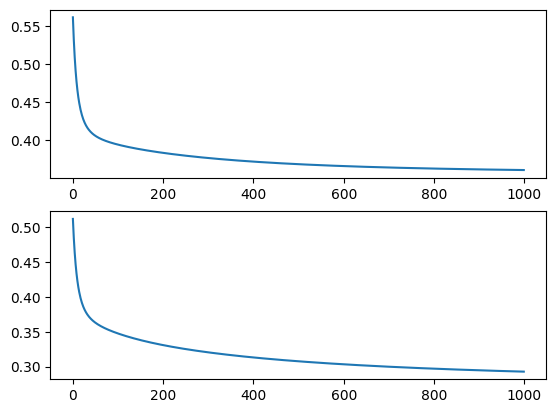

Minimum train cost: 0.3612138330936432
Minimum test cost: 0.2928694486618042

Learned Weights Summary:
Setosa weights: [[-0.8969305  2.7041385 -2.6045232 -2.0980985]]
Versicolor weights: [[ 0.41534877 -1.2508972   0.32558167 -0.7808738 ]]
Virginica weights: [[-0.46802303  0.8328723   0.83056015  2.2017593 ]]


In [16]:
### your code here

#Defining Versicolor
versicolor_model = nn.Sequential(nn.Linear(x_train.shape[1], 1, bias=False),nn.Sigmoid())
versicolor_labels = y_train[:, 1].reshape(-1, 1).float()
versicolor_testy = y_test[:, 1].reshape(-1, 1).float()
versicolor_optim = optim.SGD(versicolor_model.parameters(), lr=alpha)

#Defining Virginica
virginica_model = nn.Sequential(nn.Linear(x_train.shape[1], 1, bias=False),nn.Sigmoid())
virginica_labels = y_train[:, 2].reshape(-1, 1).float()
virginica_testy = y_test[:, 2].reshape(-1, 1).float()
virginica_optim = optim.SGD(virginica_model.parameters(), lr=alpha)


#training Versicolor and Virginica
print("Training Versicolor Classifier (1 vs all):")
train(versicolor_model, x_train, versicolor_labels, x_test, versicolor_testy, versicolor_optim, alpha)
print("\nTraining Virginica Classifier (1 vs all):")
train(virginica_model, x_train, virginica_labels, x_test, virginica_testy, virginica_optim, alpha)



# Printing learned weights for comparison
print("\nLearned Weights Summary:")
print(f"Setosa weights: {setosa_model[0].weight.detach().numpy()}")
print(f"Versicolor weights: {versicolor_model[0].weight.detach().numpy()}")
print(f"Virginica weights: {virginica_model[0].weight.detach().numpy()}")



<font color="red"> **Q7.** Using the 3 classifiers, predict the classes of the samples in the test set and show the predictions in a table. Do you observe anything interesting? [4 marks] </font>

In [17]:
### your code here

setosa_prediction = setosa_model(x_test).detach().numpy().flatten()
versicolor_prediction = versicolor_model(x_test).detach().numpy().flatten()
virginica_prediction = virginica_model(x_test).detach().numpy().flatten()

# Formatting in a table
predicted_table = pd.DataFrame({
    'Setosa Prob': setosa_prediction,
    'Versicolor Prob': versicolor_prediction,
    'Virginica Prob': virginica_prediction
})

# Getting the highest probability
predicted_table['Predicted Species'] = predicted_table[['Setosa Prob', 'Versicolor Prob', 'Virginica Prob']].idxmax(axis=1)

# Predicted species names (remove ' Prob') to make it cleaner
predicted_table['Predicted Species'] = predicted_table['Predicted Species'].str.replace(' Prob', '')

true_labels = torch.argmax(y_test, dim=1).numpy()
predicted_table['Actual Class'] = ['Setosa' if i==0 else 'Versicolor' if i==1 else 'Virginica' for i in true_labels]

# Adding column to show the accuracy of the predicted class to the actual class it is
predicted_table['Prediction Verdict'] = predicted_table['Predicted Species'] == predicted_table['Actual Class']

# Presenting the table
print("Full Predictions Table:")
print(predicted_table)
print("\n" + "="*80 + "\n")

# Summary statistics
print("Classification Summary:")
print(f"Total samples: {len(predicted_table)}")
print(f"Correct predictions: {predicted_table['Prediction Verdict'].sum()}")
print(f"Incorrect predictions: {(~predicted_table['Prediction Verdict']).sum()}")
print(f"Accuracy: {predicted_table['Prediction Verdict'].sum() / len(predicted_table) * 100:.2f}%")

print("\nMisclassified samples:")
print(predicted_table[~predicted_table['Prediction Verdict']])

# Mean, std and min, max and quartile
print("\nProbability Statistical Analysis:")
print(predicted_table[['Setosa Prob', 'Versicolor Prob', 'Virginica Prob']].describe())

Full Predictions Table:
    Setosa Prob  Versicolor Prob  Virginica Prob Predicted Species  \
0      0.032759         0.738651        0.464966        Versicolor   
1      0.999956         0.172060        0.107680            Setosa   
2      0.000003         0.841531        0.944899         Virginica   
3      0.038652         0.589397        0.707883         Virginica   
4      0.007738         0.769037        0.523656        Versicolor   
5      0.999657         0.320989        0.076695            Setosa   
6      0.292606         0.549879        0.525091        Versicolor   
7      0.002210         0.386815        0.966769         Virginica   
8      0.000478         0.917734        0.371308        Versicolor   
9      0.077866         0.734504        0.369457        Versicolor   
10     0.014230         0.347621        0.948100         Virginica   
11     0.999259         0.587868        0.021574            Setosa   
12     0.999911         0.308553        0.045667            Setosa

<font color="red"> **Q8.** Calculate the accuracy of the classifier on the test set, by comparing the predicted values against the ground truth. Use a softmax for the classifier outputs. [1 mark] </font>

In [18]:
#softmax formula 1 / (1 + e^-(z1-z2))
def softmax(y_true: torch.Tensor, logits:torch.Tensor) -> torch.Tensor:
    exp_logits = torch.exp(logits - torch.max(logits, dim=1, keepdim=True).values)
    softmax_output = exp_logits / torch.sum(exp_logits, dim=1, keepdims=True)
    return softmax_output


# raw outputs from classifiers
setosa_logs = setosa_model(x_test).detach()
versicolor_logs = versicolor_model(x_test).detach()
virginica_logs = virginica_model(x_test).detach()
logits = torch.cat([setosa_logs, versicolor_logs, virginica_logs], dim=1)


probability = softmax(None, logits)

predicted_categories = torch.argmax(probability, dim=1)
true_classes = torch.argmax(y_test, dim=1)
ground_truth = (predicted_categories == true_classes).sum().item() / len(true_classes)
print(f"Test Accuracy for Ground Truth: {ground_truth * 100:.2f}%")



Test Accuracy for Ground Truth: 90.00%


## 3. The XOR problem

<font color="red"> **Q9.** Looking at the datapoints below, can we draw a decision boundary using Logistic Regression? Why? What are the specific issues or logistic regression with regards to XOR? [2 marks] </font>

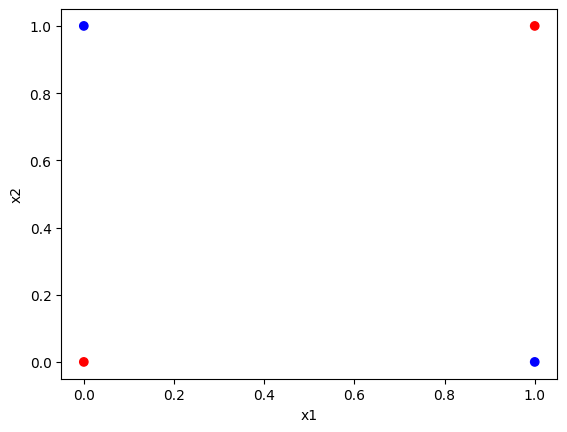

In [19]:
x1 = [0, 0, 1, 1]
x2 = [0, 1, 0, 1]
y = [0, 1, 1, 0]

c_map = ['r', 'b', 'b', 'r']
plt.scatter(x1, x2, c=c_map)
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

#The class points are diagonal to eachother, so the data can't be seperated linearly, to use XOR it would require a nonlinear model.